# **Feature Engineering**
**Tahap:** Load data → Preprocessing → Scaling → Pisah Modalitas → Seleksi Fitur (Korelasi)

Output file yang dihasilkan:
- `X_train_fisik.csv`, `X_test_fisik.csv`
- `X_train_kimia.csv`, `X_test_kimia.csv`
- `X_train_demografi.csv`, `X_test_demografi.csv`
- `y_train.npy`, `y_test.npy`

## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## **Load Dataset & Definisi Modalitas**

In [2]:
df = pd.read_csv('../data/dataset-uci.csv')

# Modalitas A: Sinyal Fisik Tubuh (Bioimpedans)
fitur_fisik = [
    'Body Mass Index (BMI)', 'Total Body Water (TBW)',
    'Extracellular Water (ECW)', 'Intracellular Water (ICW)',
    'Extracellular Fluid/Total Body Water (ECF/TBW)',
    'Total Body Fat Ratio (TBFR) (%)', 'Lean Mass (LM) (%)',
    'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)',
    'Bone Mass (BM)', 'Muscle Mass (MM)', 'Obesity (%)',
    'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)',
    'Visceral Muscle Area (VMA) (Kg)'
]

# Modalitas B: Sinyal Kimia Tubuh (Lab Darah)
fitur_kimia = [
    'Glucose', 'Total Cholesterol (TC)',
    'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)',
    'Triglyceride', 'Aspartat Aminotransferaz (AST)',
    'Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)',
    'Creatinine', 'Glomerular Filtration Rate (GFR)',
    'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D'
]

# Modalitas C: Data Kontrol Baseline (Demografis)
fitur_demografi = [
    'Age', 'Gender', 'Comorbidity',
    'Coronary Artery Disease (CAD)',
    'Hypothyroidism', 'Hyperlipidemia',
    'Diabetes Mellitus (DM)'
]

fitur_keseluruhan = fitur_demografi + fitur_fisik + fitur_kimia
X = df[fitur_keseluruhan]
y = df['Gallstone Status']

print(f'Total fitur  : {X.shape[1]}')
print(f'Total sampel : {X.shape[0]}')
print(f'Distribusi label:\n{y.value_counts()}')

Total fitur  : 35
Total sampel : 319
Distribusi label:
Gallstone Status
0    161
1    158
Name: count, dtype: int64


## **Train-Test Split**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')

Train : (255, 35)
Test  : (64, 35)


## **Standard Scaling**

In [4]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

print('Scaling selesai!')

Scaling selesai!


## **Pemisahan Fitur Per Modalitas**

In [5]:
X_train_fisik     = X_train_scaled[fitur_fisik]
X_train_kimia     = X_train_scaled[fitur_kimia]
X_train_demografi = X_train_scaled[fitur_demografi]

X_test_fisik     = X_test_scaled[fitur_fisik]
X_test_kimia     = X_test_scaled[fitur_kimia]
X_test_demografi = X_test_scaled[fitur_demografi]

print('Pemisahan modalitas selesai!')
print(f'  Modalitas A (Fisik)    : {X_train_fisik.shape[1]} fitur')
print(f'  Modalitas B (Kimia)    : {X_train_kimia.shape[1]} fitur')
print(f'  Modalitas C (Demografi): {X_train_demografi.shape[1]} fitur')

Pemisahan modalitas selesai!
  Modalitas A (Fisik)    : 15 fitur
  Modalitas B (Kimia)    : 13 fitur
  Modalitas C (Demografi): 7 fitur


## **Seleksi Fitur — Analisis Korelasi**
Fitur dengan korelasi > 0.85 terhadap fitur lain dianggap redundan dan akan dihapus.

In [6]:
def drop_high_corr(df_train, df_test, threshold=0.85, label=''):
    corr_matrix = df_train.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f'[{label}] Fitur dihapus ({len(to_drop)}): {to_drop}')
    print(f'[{label}] Fitur tersisa: {df_train.shape[1] - len(to_drop)}')
    return df_train.drop(columns=to_drop), df_test.drop(columns=to_drop), to_drop

X_train_fisik, X_test_fisik, dropped_fisik = drop_high_corr(
    X_train_fisik, X_test_fisik, threshold=0.85, label='Fisik'
)
X_train_kimia, X_test_kimia, dropped_kimia = drop_high_corr(
    X_train_kimia, X_test_kimia, threshold=0.85, label='Kimia'
)

[Fisik] Fitur dihapus (6): ['Extracellular Water (ECW)', 'Lean Mass (LM) (%)', 'Bone Mass (BM)', 'Muscle Mass (MM)', 'Total Fat Content (TFC)', 'Visceral Fat Area (VFA)']
[Fisik] Fitur tersisa: 9
[Kimia] Fitur dihapus (0): []
[Kimia] Fitur tersisa: 13


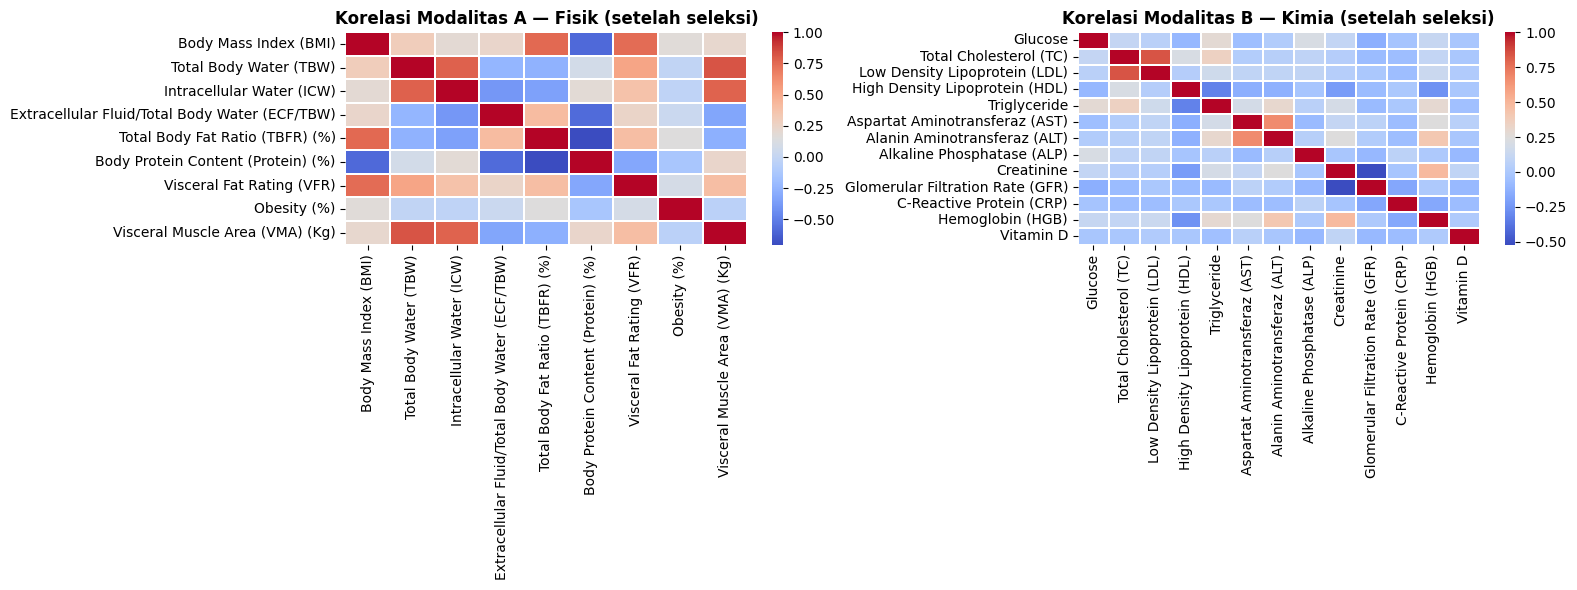

Fitur Fisik final  : ['Body Mass Index (BMI)', 'Total Body Water (TBW)', 'Intracellular Water (ICW)', 'Extracellular Fluid/Total Body Water (ECF/TBW)', 'Total Body Fat Ratio (TBFR) (%)', 'Body Protein Content (Protein) (%)', 'Visceral Fat Rating (VFR)', 'Obesity (%)', 'Visceral Muscle Area (VMA) (Kg)']
Fitur Kimia final  : ['Glucose', 'Total Cholesterol (TC)', 'Low Density Lipoprotein (LDL)', 'High Density Lipoprotein (HDL)', 'Triglyceride', 'Aspartat Aminotransferaz (AST)', 'Alanin Aminotransferaz (ALT)', 'Alkaline Phosphatase (ALP)', 'Creatinine', 'Glomerular Filtration Rate (GFR)', 'C-Reactive Protein (CRP)', 'Hemoglobin (HGB)', 'Vitamin D']


In [9]:
# Heatmap Korelasi Modalitas A (setelah seleksi)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    X_train_fisik.corr(), annot=False, cmap='coolwarm',
    linewidths=0.3, ax=axes[0]
)
axes[0].set_title('Korelasi Modalitas A — Fisik (setelah seleksi)', fontweight='bold')

sns.heatmap(
    X_train_kimia.corr(), annot=False, cmap='coolwarm',
    linewidths=0.3, ax=axes[1]
)
axes[1].set_title('Korelasi Modalitas B — Kimia (setelah seleksi)', fontweight='bold')

plt.tight_layout()
plt.savefig('../result/heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Fitur Fisik final  : {list(X_train_fisik.columns)}')
print(f'Fitur Kimia final  : {list(X_train_kimia.columns)}')

## **Simpan Output untuk Modeling**

In [10]:
# Simpan subset per modalitas
X_train_fisik.to_csv('../prepare/X_train_fisik.csv', index=False)
X_test_fisik.to_csv('../prepare/X_test_fisik.csv', index=False)

X_train_kimia.to_csv('../prepare/X_train_kimia.csv', index=False)
X_test_kimia.to_csv('../prepare/X_test_kimia.csv', index=False)

X_train_demografi.to_csv('../prepare/X_train_demografi.csv', index=False)
X_test_demografi.to_csv('../prepare/X_test_demografi.csv', index=False)

# Simpan label
np.save('../prepare/y_train.npy', y_train.values)
np.save('../prepare/y_test.npy', y_test.values)

print('Semua file berhasil disimpan!')
print('  ../prepare/X_train_fisik.csv, ../prepare/X_test_fisik.csv')
print('  ../prepare/X_train_kimia.csv, ../prepare/X_test_kimia.csv')
print('  ../prepare/X_train_demografi.csv, ../prepare/X_test_demografi.csv')
print('  ../prepare/y_train.npy, ../prepare/y_test.npy')

Semua file berhasil disimpan!
  ../prepare/X_train_fisik.csv, ../prepare/X_test_fisik.csv
  ../prepare/X_train_kimia.csv, ../prepare/X_test_kimia.csv
  ../prepare/X_train_demografi.csv, ../prepare/X_test_demografi.csv
  ../prepare/y_train.npy, ../prepare/y_test.npy
